# Data analisis and clients churn predictionАналіз
## Telecomunication company

This jupiter notebook contains:
1. Exploartory data analysis (EDA)
2. Visualisation of distributions
3. Correlation analysis
4. Data preparation for modeling
5. Model training and evaluation

In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setting up visualization
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.metrics import classification_report

# Libraries for gradient boosting
import xgboost as xgb
import lightgbm as lgb


## 2. Data loading

In [2]:
# Data loading
df = pd.read_csv('../data/raw/internet_service_churn.csv', na_values=['', ' ', 'NA', 'null', 'NULL'])
print(f"Size of data: {df.shape}")
df.head()

Size of data: (72274, 11)


,id,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn
0,15,1,0,11.95,25,0.14,0,8.4,2.3,0,0
1,18,0,0,8.22,0,NaN,0,0.0,0.0,0,1
2,23,1,0,8.91,16,0.00,0,13.7,0.9,0,1
3,27,0,0,6.87,21,NaN,1,0.0,0.0,0,1
4,34,0,0,6.39,0,NaN,0,0.0,0.0,0,1


In [3]:
# Basic information about the data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72274 entries, 0 to 72273
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           72274 non-null  int64  
 1   is_tv_subscriber             72274 non-null  int64  
 2   is_movie_package_subscriber  72274 non-null  int64  
 3   subscription_age             72274 non-null  float64
 4   bill_avg                     72274 non-null  int64  
 5   remaining_contract           50702 non-null  float64
 6   service_failure_count        72274 non-null  int64  
 7   download_avg                 71893 non-null  float64
 8   upload_avg                   71893 non-null  float64
 9   download_over_limit          72274 non-null  int64  
 10  churn                        72274 non-null  int64  
dtypes: float64(4), int64(7)
memory usage: 6.1 MB


## 3. Exploratory data analysis(EDA)

In [4]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})
missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

,Missing Values,Percentage (%)
remaining_contract,21572,29.847525
download_avg,381,0.527161
upload_avg,381,0.527161


<Figure size 1000x600 with 0 Axes>

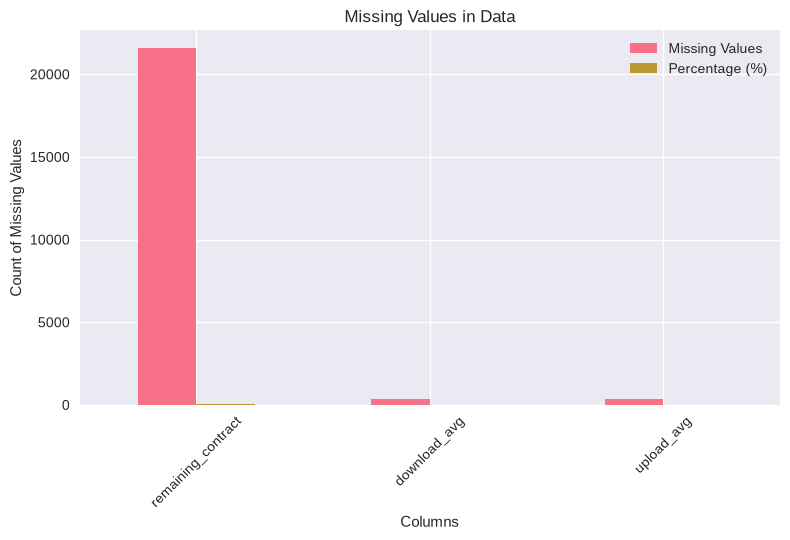

In [5]:
# Visualization of missing values
plt.figure(figsize=(10, 6))
missing_df[missing_df['Missing Values'] > 0].plot(kind='bar')
plt.title('Missing Values in Data')
plt.xlabel('Columns')
plt.ylabel('Count of Missing Values')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 Distribution of target vaiable (churn)

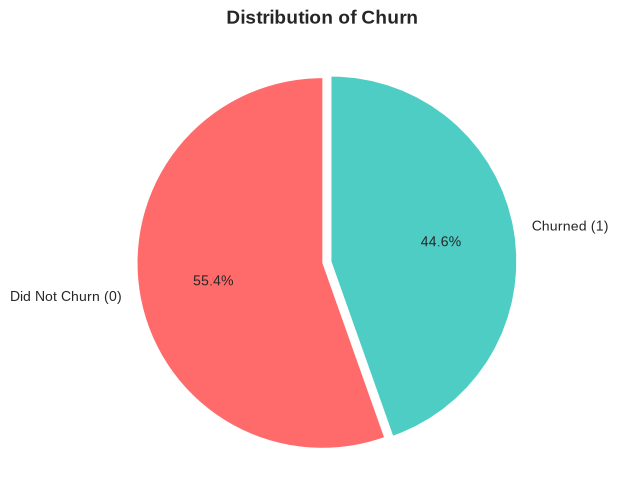


Number of customers with churn: 40050
Number of customers without churn: 32224
Churn rate: 55.41%


In [6]:
# Distribution of churn
plt.figure(figsize=(8, 6))
churn_counts = df['churn'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
plt.pie(churn_counts.values, labels=['Did Not Churn (0)', 'Churned (1)'], 
        autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05))
plt.title('Distribution of Churn', fontsize=14, fontweight='bold')
plt.show()

print(f"\nNumber of customers with churn: {df['churn'].sum()}")
print(f"Number of customers without churn: {len(df) - df['churn'].sum()}")
print(f"Churn rate: {df['churn'].mean()*100:.2f}%")

### 3.3 Distribution of numerical features

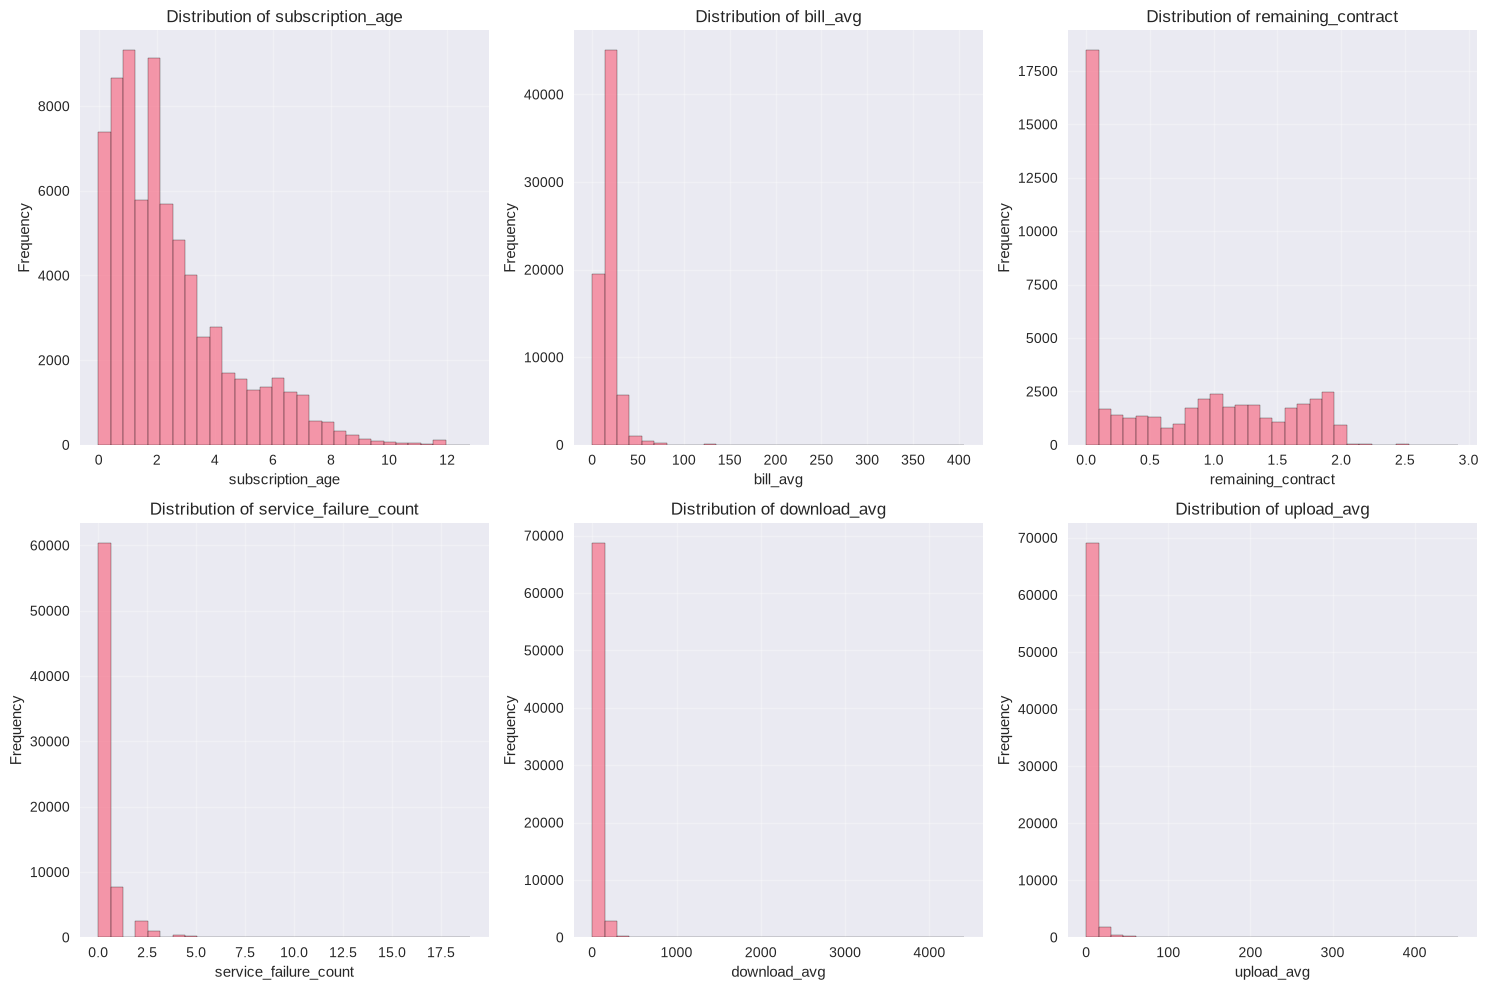

In [7]:
# Histograms of numerical features
numeric_cols = ['subscription_age', 'bill_avg', 'remaining_contract', 
                'service_failure_count', 'download_avg', 'upload_avg']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Categorical features analysis

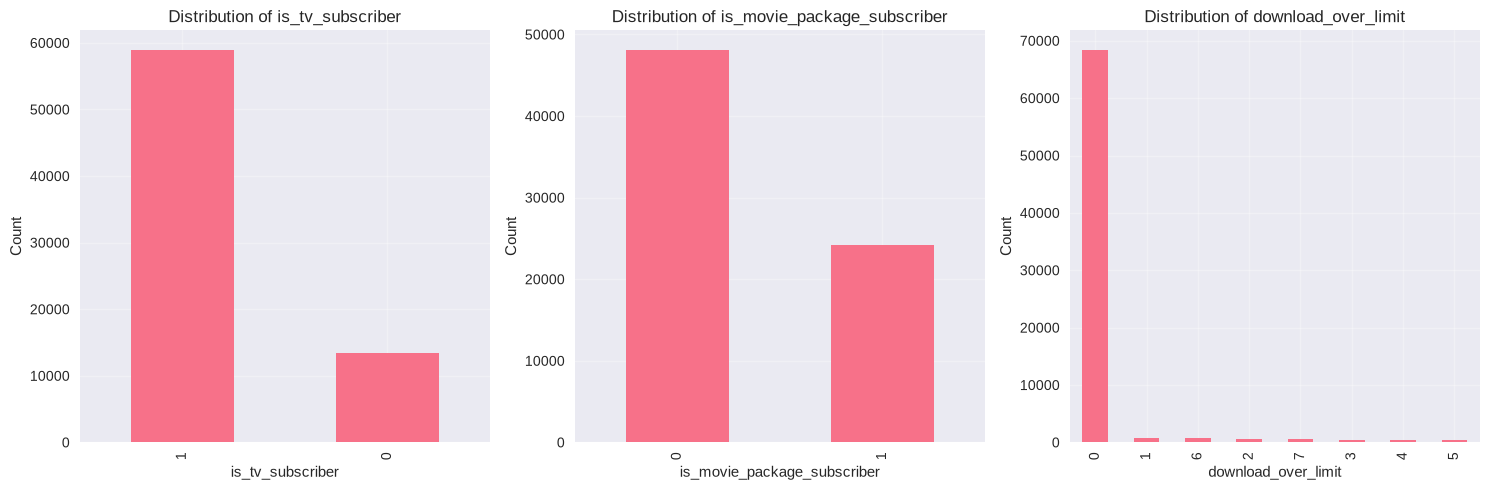

In [8]:
# Categorical features
cat_cols = ['is_tv_subscriber', 'is_movie_package_subscriber', 'download_over_limit']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.5 Churn by Categorical Features analysis

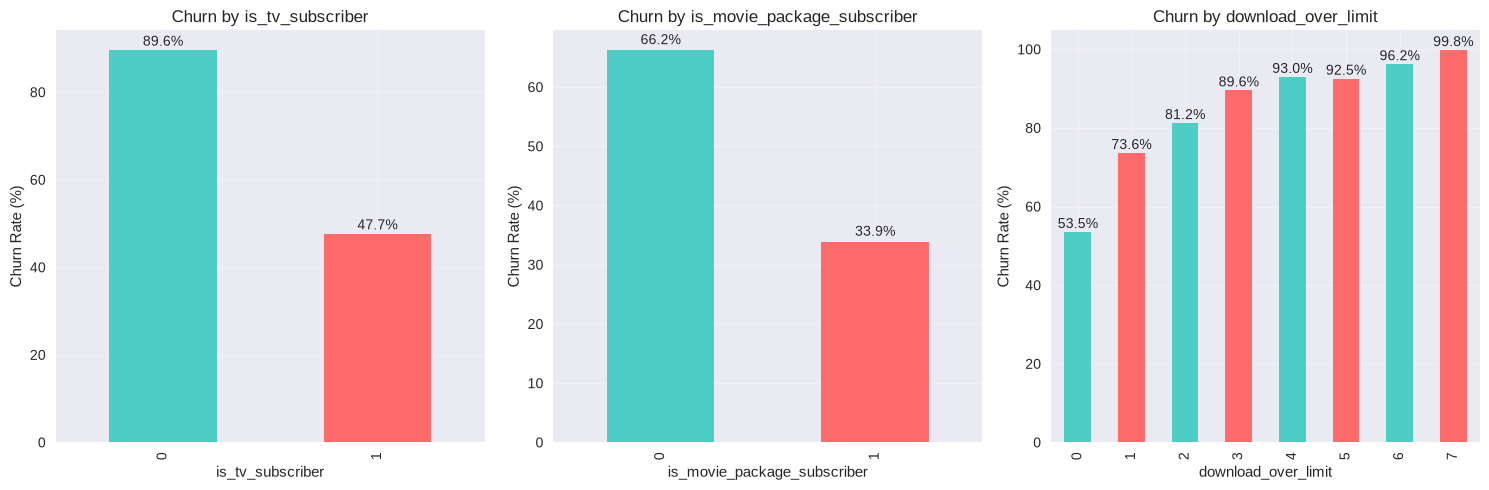

In [9]:
# Churn by Categorical Features
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    churn_by_cat = df.groupby(col)['churn'].mean() * 100
    churn_by_cat.plot(kind='bar', ax=axes[idx], color=['#4ECDC4', '#FF6B6B'])
    axes[idx].set_title(f'Churn by {col}', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Churn Rate (%)')
    axes[idx].grid(True, alpha=0.3)
    for i, v in enumerate(churn_by_cat):
        axes[idx].text(i, v + 1, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.show()

### 3.6 Correlation analysis

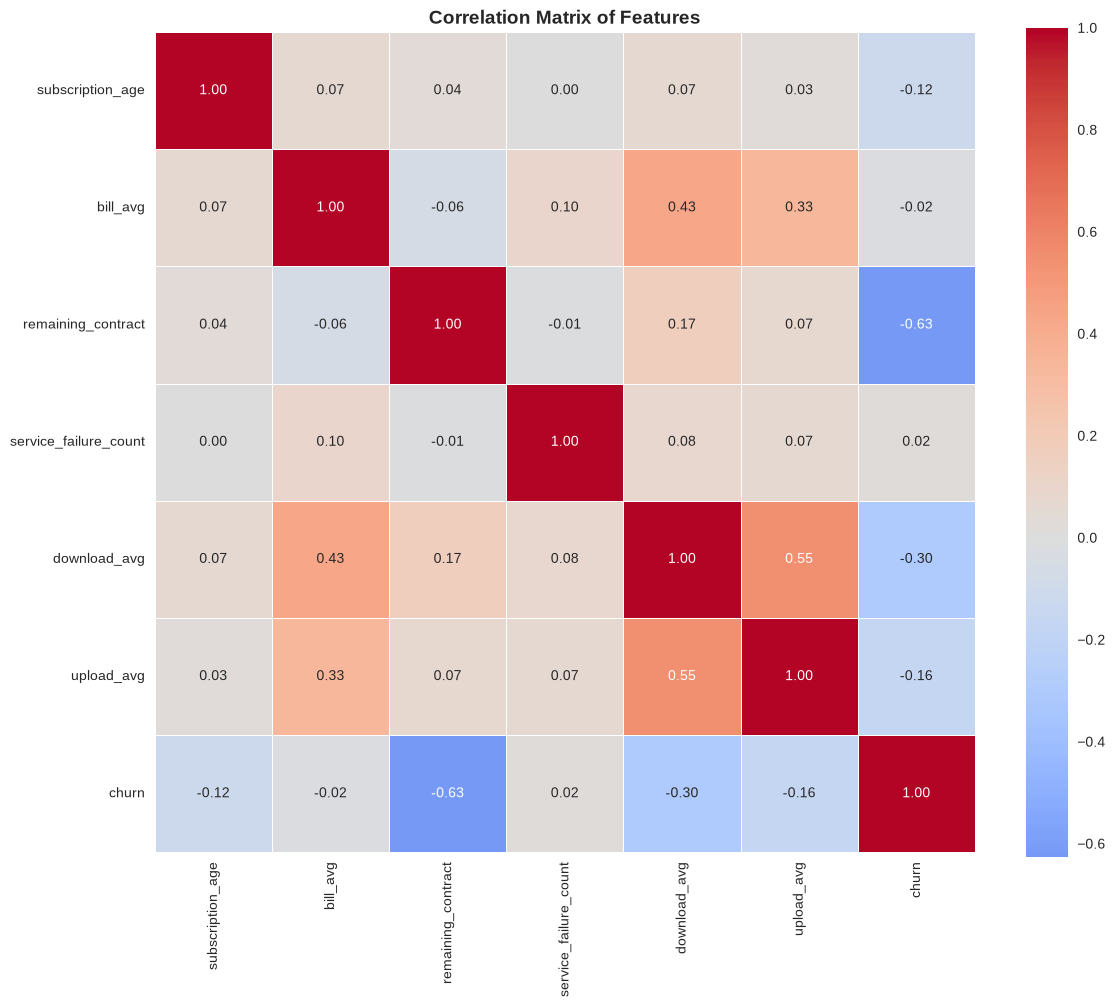

In [10]:
# Correlation Matrix
plt.figure(figsize=(12, 10))
corr_matrix = df[numeric_cols + ['churn']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Correlation Matrix of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

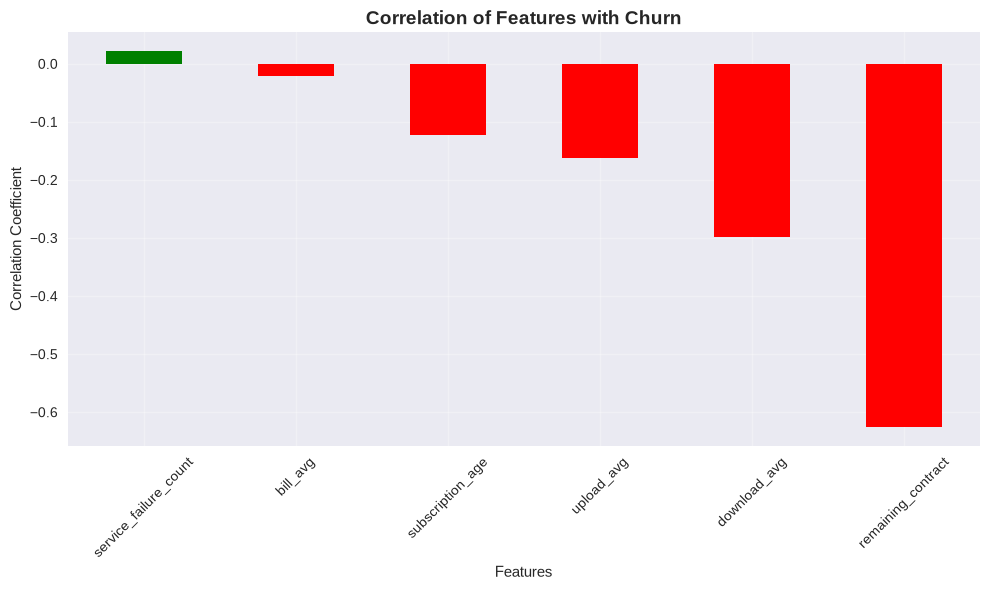

In [11]:
# Correlation with Target Variable
churn_corr = df[numeric_cols + ['churn']].corr()['churn'].sort_values(ascending=False)
churn_corr = churn_corr[churn_corr.index != 'churn']

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in churn_corr.values]
churn_corr.plot(kind='bar', color=colors)
plt.title('Correlation of Features with Churn', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.7 Analysis of churn by numerical features

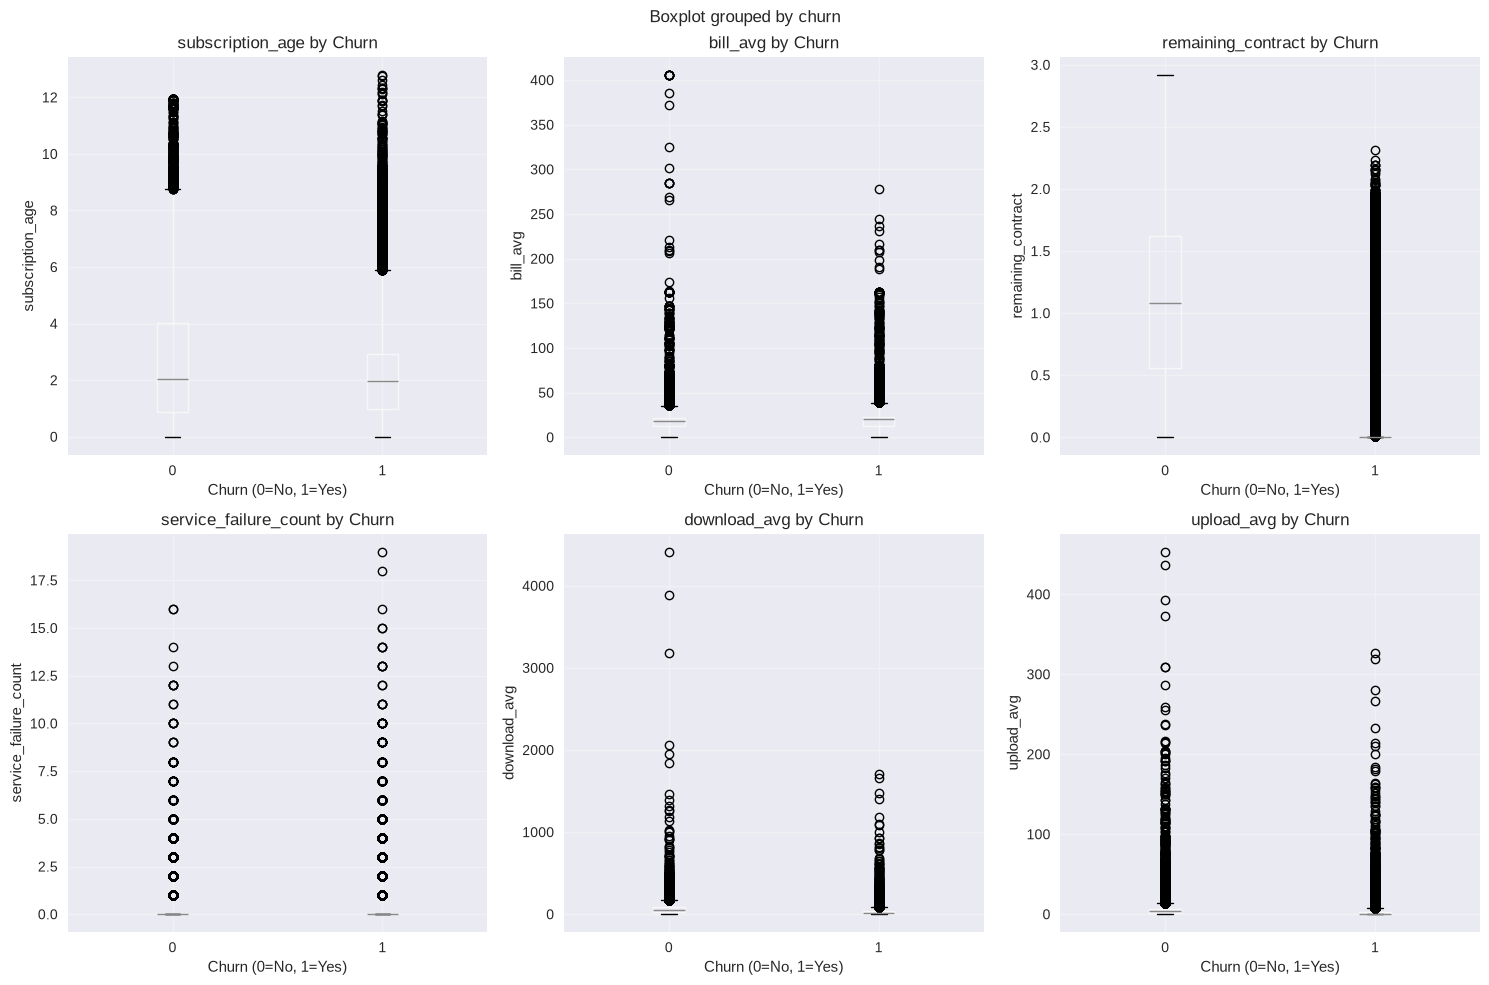

In [12]:
# Box plots for numerical features by churn
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    df.boxplot(column=col, by='churn', ax=axes[idx])
    axes[idx].set_title(f'{col} by Churn', fontsize=12)
    axes[idx].set_xlabel('Churn (0=No, 1=Yes)')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Data preparation for modeling

In [13]:
# Copy data for processing
df_processed = df.copy()

# Dropping the id column
df_processed = df_processed.drop('id', axis=1)

# Handling missing values
df_processed['remaining_contract_missing'] = df_processed['remaining_contract'].isnull().astype(int)
df_processed['remaining_contract'] = df_processed['remaining_contract'].fillna(df_processed['remaining_contract'].median())
df_processed['download_avg'] = df_processed['download_avg'].fillna(df_processed['download_avg'].median())
df_processed['upload_avg'] = df_processed['upload_avg'].fillna(df_processed['upload_avg'].median())

print("Missing values after processing:")
print(df_processed.isnull().sum())

Missing values after processing:
is_tv_subscriber               0
is_movie_package_subscriber    0
subscription_age               0
bill_avg                       0
remaining_contract             0
service_failure_count          0
download_avg                   0
upload_avg                     0
download_over_limit            0
churn                          0
remaining_contract_missing     0
dtype: int64


In [14]:
# Encoding categorical variables
le = LabelEncoder()
cat_cols = ['is_tv_subscriber', 'is_movie_package_subscriber', 'download_over_limit']

for col in cat_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

print("Data after encoding:")
df_processed.head()

Data after encoding:


,is_tv_subscriber,is_movie_package_subscriber,subscription_age,bill_avg,remaining_contract,service_failure_count,download_avg,upload_avg,download_over_limit,churn,remaining_contract_missing
0,1,0,11.95,25,0.14,0,8.4,2.3,0,0,0
1,0,0,8.22,0,0.57,0,0.0,0.0,0,1,1
2,1,0,8.91,16,0.00,0,13.7,0.9,0,1,0
3,0,0,6.87,21,0.57,1,0.0,0.0,0,1,1
4,0,0,6.39,0,0.57,0,0.0,0.0,0,1,1


In [15]:
# Splitting into features and target
X = df_processed.drop('churn', axis=1)
y = df_processed['churn']

# 1. First, we split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scaling after splitting
scaler = StandardScaler()

# Train the scaler ONLY on X_train and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test using the already trained scaler (without fit!)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for convenience (preserving column names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print(f"Number of features: {X.shape[1]}")
print(f"Training set (X_train): {X_train_scaled.shape}")
print(f"Test set (X_test): {X_test_scaled.shape}")

Number of features: 10
Training set (X_train): (57819, 10)
Test set (X_test): (14455, 10)


In [16]:
# Assign the scaled data for further use
X_train = X_train_scaled
X_test = X_test_scaled

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nDistribution in training set:")
print(f"  Churn: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  No Churn: {len(y_train) - y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")
print(f"\nDistribution in test set:")
print(f"  Churn: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"  No Churn: {len(y_test) - y_test.sum()} ({(1-y_test.mean())*100:.1f}%)")

Training set: 57819 samples
Test set: 14455 samples

Distribution in training set:
  Churn: 32040 (55.4%)
  No Churn: 25779 (44.6%)

Distribution in test set:
  Churn: 8010 (55.4%)
  No Churn: 6445 (44.6%)


## 5. Models learning

In [17]:
# Function the model evaluation
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
    }
    
    return metrics, y_pred, y_pred_proba

In [18]:
# List of models to evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
}

# Learn and evaluate models
results = []

for name, model in models.items():
    print(f"Learning: {name}...")
    model.fit(X_train, y_train)
    metrics, y_pred, y_pred_proba = evaluate_model(model, X_test, y_test, name)
    results.append(metrics)
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  ROC-AUC: {metrics['ROC-AUC']:.4f}")
    print()

Learning: Logistic Regression...
  Accuracy: 0.8764
  ROC-AUC: 0.9310

Learning: Random Forest...
  Accuracy: 0.9408
  ROC-AUC: 0.9809

Learning: Gradient Boosting...
  Accuracy: 0.9367
  ROC-AUC: 0.9740

Learning: XGBoost...
  Accuracy: 0.9425
  ROC-AUC: 0.9823

Learning: LightGBM...
  Accuracy: 0.9418
  ROC-AUC: 0.9818



In [19]:
# Comparison of models
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,XGBoost,0.942511,0.956041,0.939451,0.947673,0.982346
4,LightGBM,0.941819,0.956217,0.937953,0.946997,0.981807
1,Random Forest,0.940782,0.957066,0.935081,0.945946,0.980903
2,Gradient Boosting,0.936700,0.954866,0.929713,0.942122,0.973959
0,Logistic Regression,0.876375,0.874744,0.906742,0.890455,0.930983


### 5.1 Visualisation of models comparison

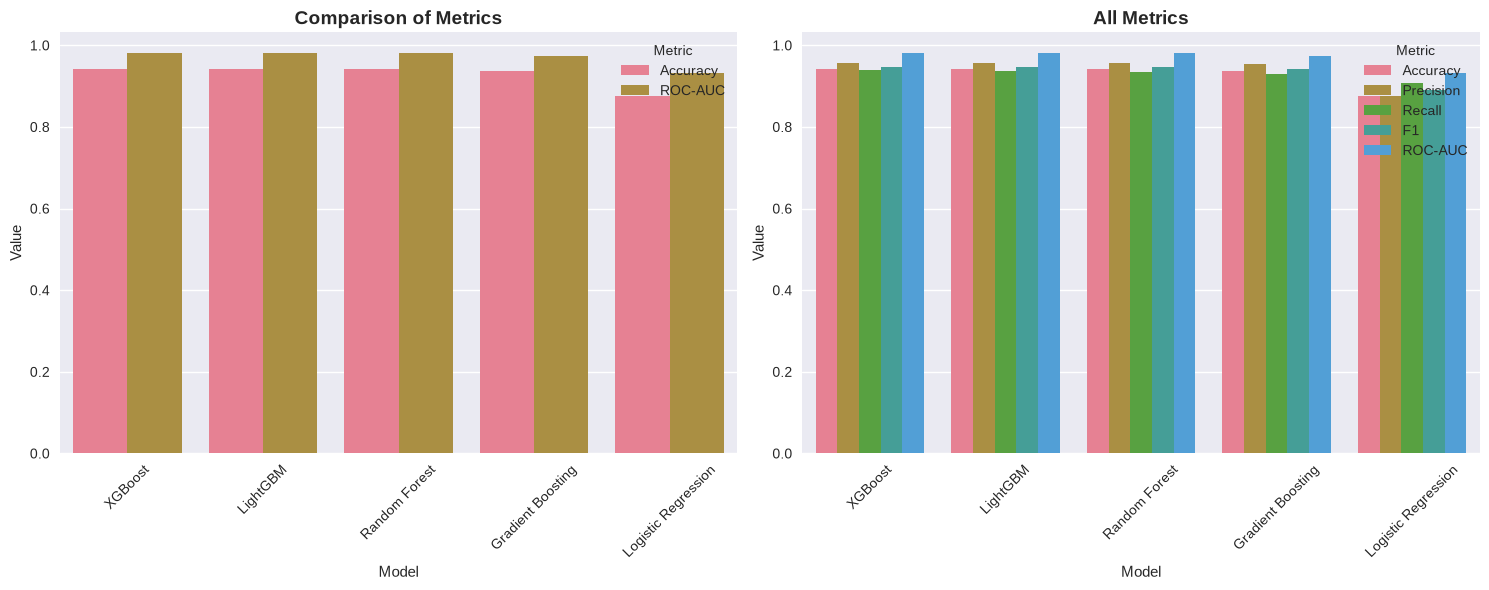

In [20]:
# Comparison of metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy and ROC-AUC
results_df_melted = results_df.melt(id_vars=['Model'], value_vars=['Accuracy', 'ROC-AUC'])
sns.barplot(data=results_df_melted, x='Model', y='value', hue='variable', ax=axes[0])
axes[0].set_title('Comparison of Metrics', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].set_xlabel('Model')
axes[0].legend(title='Metric')
axes[0].tick_params(axis='x', rotation=45)

# All metrics
results_df_melted_all = results_df.melt(id_vars=['Model'], 
                                       value_vars=['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC'])
sns.barplot(data=results_df_melted_all, x='Model', y='value', hue='variable', ax=axes[1])
axes[1].set_title('All Metrics', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].set_xlabel('Model')
axes[1].legend(title='Metric')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Аналіз найкращої моделі

In [21]:
# Select the best model
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")
print(f"Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"ROC-AUC: {results_df.iloc[0]['ROC-AUC']:.4f}")

Best model: XGBoost
Accuracy: 0.9425
ROC-AUC: 0.9823


In [22]:
# Prediction for the best model
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

### 6.1 Confusion Matrix

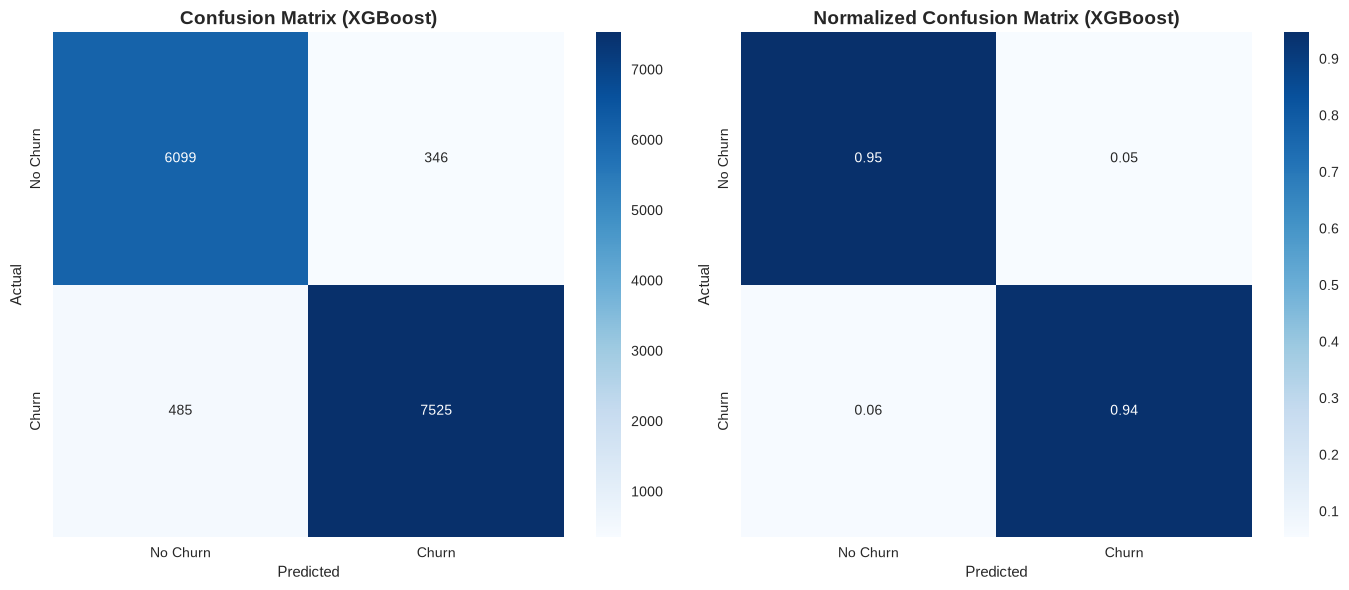

In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix ({best_model_name})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])

# Normalized Confusion Matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1])
axes[1].set_title(f'Normalized Confusion Matrix ({best_model_name})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['No Churn', 'Churn'])
axes[1].set_yticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

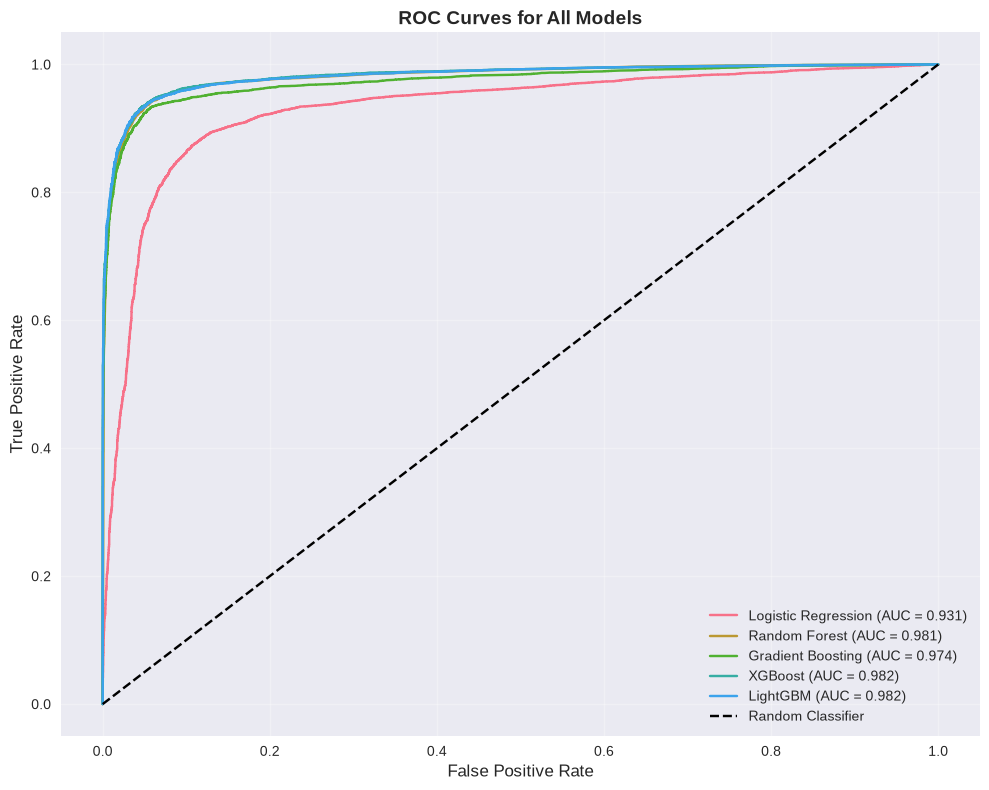

In [24]:
# ROC-curve for all models
plt.figure(figsize=(10, 8))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Importance of the features

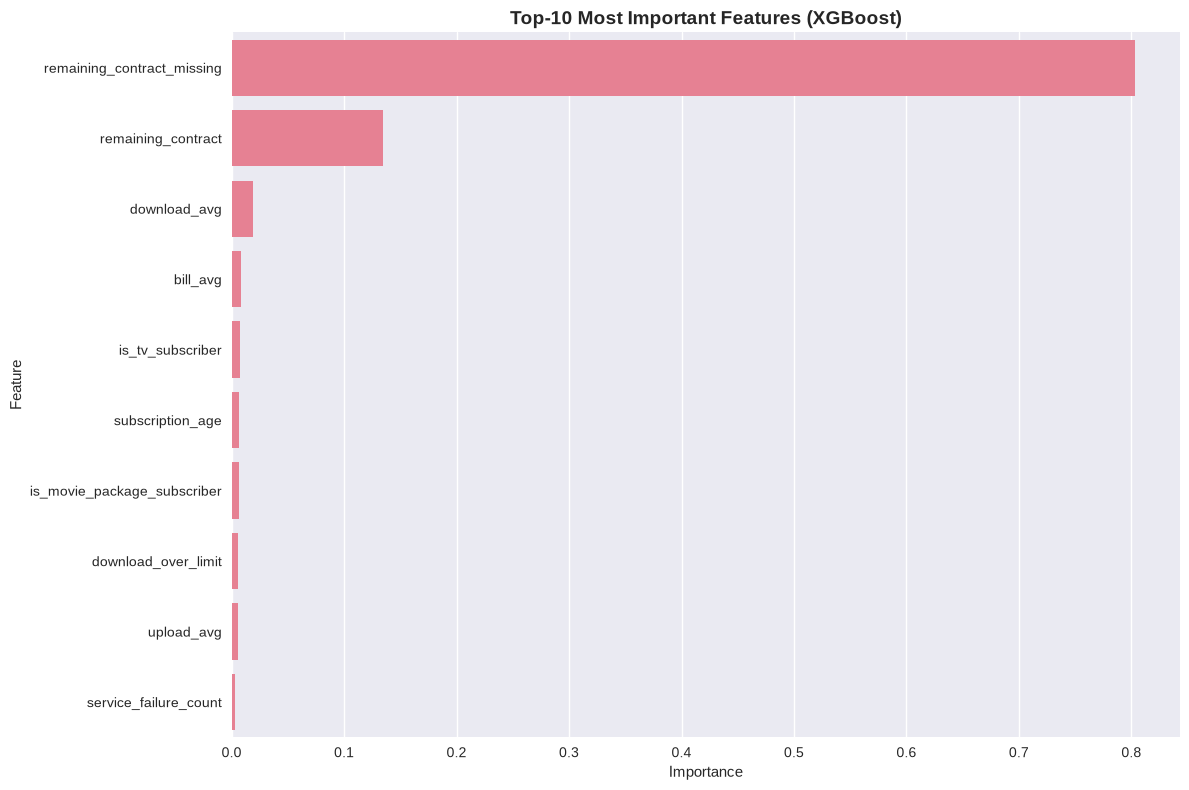


Top-5 Most Important Features:
  remaining_contract_missing: 0.803
  remaining_contract: 0.135
  download_avg: 0.019
  bill_avg: 0.008
  is_tv_subscriber: 0.008


In [25]:
# Importance of Features for the Best Model
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature')
    plt.title(f'Top-10 Most Important Features ({best_model_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
    
    print("\nTop-5 Most Important Features:")
    for _, row in feature_importance.head(5).iterrows():
        print(f"  {row['Feature']}: {row['Importance']:.3f}")

### 6.4 Classification report

In [26]:
print("Classification report for the best model:")
print("=" * 50)
print(classification_report(y_test, y_pred_best, target_names=['No Churn', 'Churn']))

Classification report for the best model:
              precision    recall  f1-score   support

    No Churn       0.93      0.95      0.94      6445
       Churn       0.96      0.94      0.95      8010

    accuracy                           0.94     14455
   macro avg       0.94      0.94      0.94     14455
weighted avg       0.94      0.94      0.94     14455



## 7. Conclusions

1. **Data**: 72,274 clients, churn level is 55.4%.
2. **The most important features**: 
   - `remaining_contract_missing` (absence contract data) and `remaining_contract` (remaining contract term) cover over 93% of the model importance;
   - Certain impact also does `download_avg` (download volume) and `bill_avg` (average bill).
3. **Best model**: XGBoost with accuracy (Accuracy) **94.25%** and **ROC-AUC 0.9823**.
4. **Main conclusions**:
- The model clearly and qualitatively distinguishes customers with high and low churn risk (F1-score = 0.95 for the Churn class);
- Features related to the presence and duration of the contract are determining factors in predicting churn;
- Due to scaling after data separation (without data leakage), the accuracy assessment is completely objective.
5. **Recommendations**:
- Implement the XGBoost model as the main one for automatic ranking of customers by churn risk;
- Pay special attention to customers with missed/expiring contract terms and develop retention programs for them (contract extension, bonuses);
- Apply personalized marketing offers for high-risk categories.